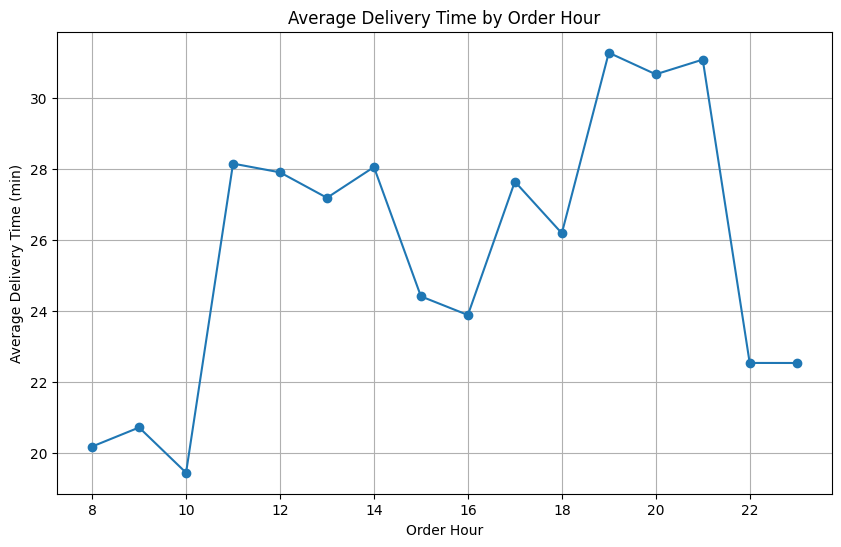

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("updated.csv")

# Convert order time to datetime
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M",
    errors="coerce"
)

# Remove invalid times like 10:60
df = df.dropna(subset=["Time_Orderd"])

# Extract hour
df["Order_Hour"] = df["Time_Orderd"].dt.hour

# Average delivery time by hour
avg_time = df.groupby("Order_Hour")["Time_taken(min)"].mean()

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    avg_time.index,
    avg_time.values,
    marker='o'
)

# Labels and title
plt.title("Average Delivery Time by Order Hour")
plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (min)")

# Grid lines
plt.grid(True)

# Show plot
plt.show()

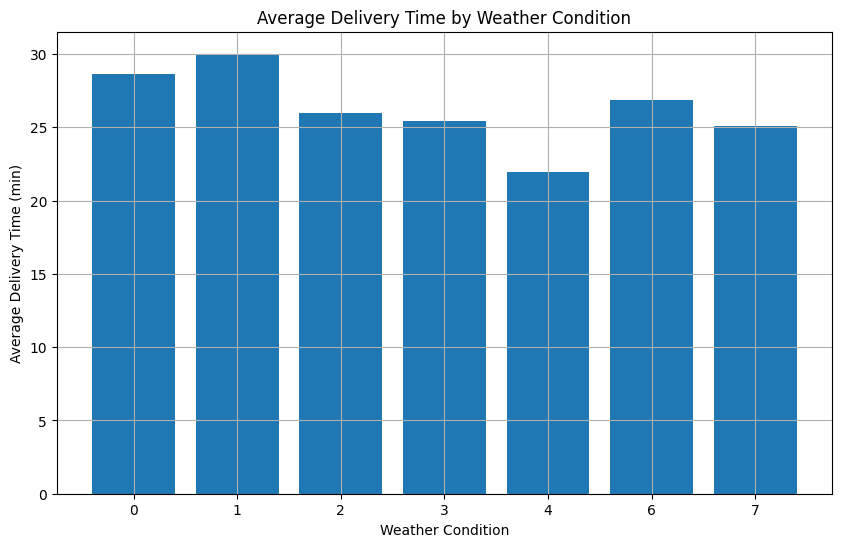

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("updated.csv")

# Group by weather condition
weather_avg = df.groupby("Weatherconditions")["Time_taken(min)"].mean()

# Plot graph
plt.figure(figsize=(10,6))

plt.bar(
    weather_avg.index.astype(str),
    weather_avg.values
)

# Labels
plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (min)")

# Grid lines
plt.grid(True)

# Show graph
plt.show()

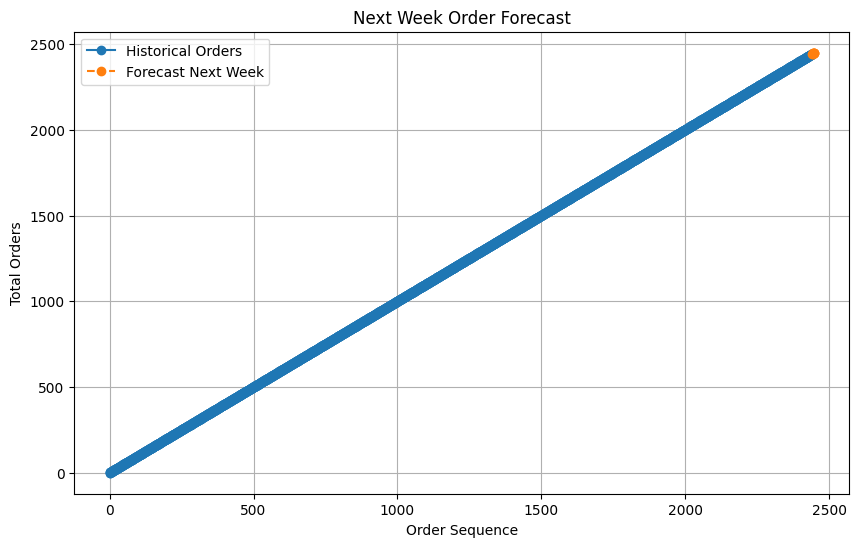

Predicted Orders for Next Week:
[1. 1. 1. 1. 1. 1. 1.]


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("updated.csv")

# Create sequential order numbers
df["Order_Number"] = np.arange(len(df))

# Features (X)
X = df[["Order_Number"]]

# Target (y)
# Assuming each row = 1 order
y = np.ones(len(df))

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Create future data for next 7 predictions
future_orders = pd.DataFrame({
    "Order_Number": np.arange(len(df), len(df) + 7)
})

# Predict future orders
predictions = model.predict(future_orders)

# Historical cumulative orders
historical_orders = y.cumsum()

# Forecast cumulative orders
forecast_orders = predictions.cumsum() + historical_orders[-1]

# Plot graph
plt.figure(figsize=(10,6))

# Historical trend
plt.plot(
    df["Order_Number"],
    historical_orders,
    label="Historical Orders",
    marker='o'
)

# Forecast trend
plt.plot(
    future_orders["Order_Number"],
    forecast_orders,
    label="Forecast Next Week",
    linestyle='dashed',
    marker='o'
)

# Labels and titlea
plt.title("Next Week Order Forecast")
plt.xlabel("Order Sequence")
plt.ylabel("Total Orders")

# Grid lines
plt.grid(True)

# Legend
plt.legend()

# Show graph
plt.show()

# Print predictions
print("Predicted Orders for Next Week:")
print(predictions)